First 5 rows of raw data:
   id route        date  scheduled_time     actual_time weather  distance_km
0   1    R1  2024-01-01 0 days 08:00:00 0 days 08:10:00    Rain         12.0
1   2    R2  2024-01-01 0 days 09:00:00 0 days 09:02:00   Clear          8.0
2   3    R1  2024-01-01 0 days 10:00:00 0 days 10:15:00    Rain         12.0
3   4    R3  2024-01-02 0 days 08:30:00 0 days 08:40:00     Fog         15.0
4   5    R2  2024-01-02 0 days 11:00:00 0 days 11:20:00   Clear          8.0

Processed DataFrame:
  route  scheduled_datetime     actual_datetime  delay_minutes delay_category
0    R1 2024-01-01 08:00:00 2024-01-01 08:10:00           10.0        Delayed
1    R2 2024-01-01 09:00:00 2024-01-01 09:02:00            2.0        On Time
2    R1 2024-01-01 10:00:00 2024-01-01 10:15:00           15.0        Delayed
3    R3 2024-01-02 08:30:00 2024-01-02 08:40:00           10.0        Delayed
4    R2 2024-01-02 11:00:00 2024-01-02 11:20:00           20.0        Delayed


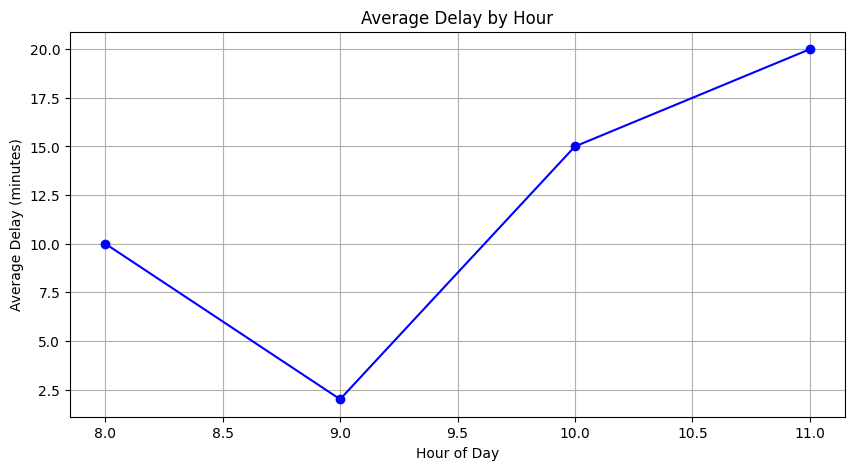

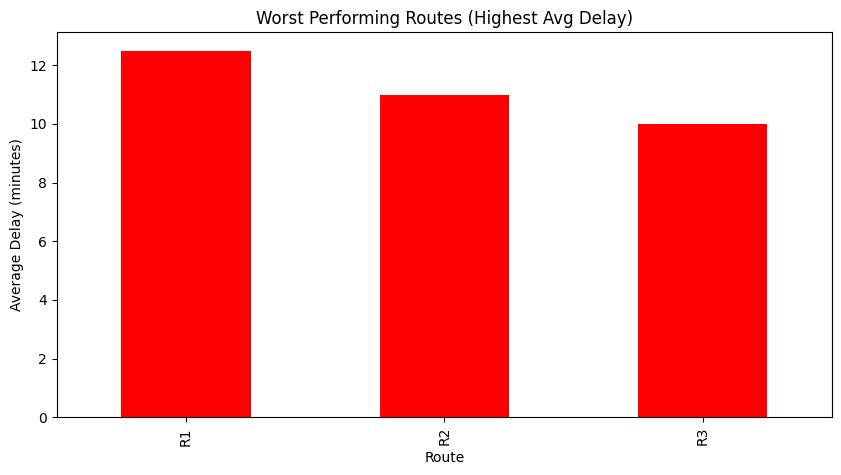

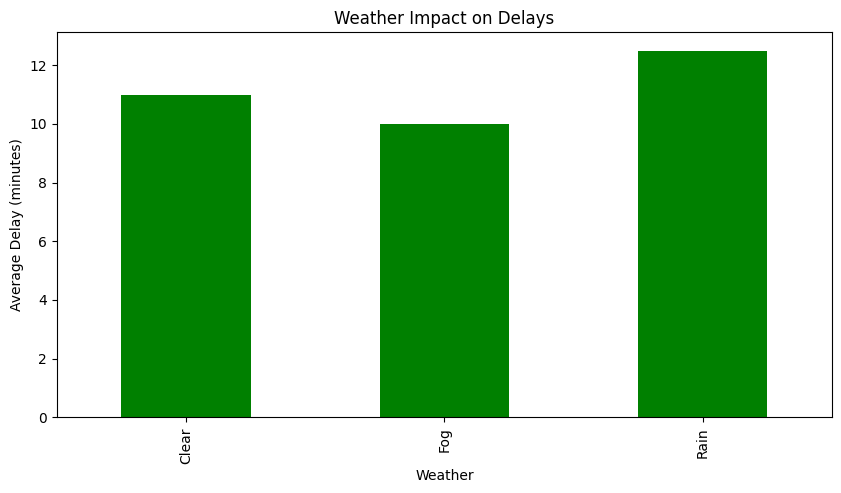


Analysis Complete ✅


In [1]:

import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# STEP 1: CONNECT TO MYSQL
# ------------------------------------------

db = mysql.connector.connect(
    host="localhost",
    user="root",          # your MySQL username
    password="ashu1234",  # your MySQL password
    database="transport_db"
)

cursor = db.cursor()

# ------------------------------------------
# STEP 2: LOAD DATA FROM MYSQL
# ------------------------------------------

cursor.execute("SELECT * FROM transport_delays")
data = cursor.fetchall()

# Create DataFrame
df = pd.DataFrame(data, columns=[i[0] for i in cursor.description])
print("First 5 rows of raw data:")
print(df.head())

# ------------------------------------------
# STEP 3: DATA PROCESSING
# ------------------------------------------

# Convert 'date' column to datetime.date
df['date'] = pd.to_datetime(df['date']).dt.date

# Combine 'date' + 'scheduled_time' and 'actual_time' to get full datetime
df['scheduled_datetime'] = df.apply(
    lambda row: pd.Timestamp.combine(row['date'], (pd.Timestamp('00:00:00') + row['scheduled_time']).time()), axis=1
)
df['actual_datetime'] = df.apply(
    lambda row: pd.Timestamp.combine(row['date'], (pd.Timestamp('00:00:00') + row['actual_time']).time()), axis=1
)

# Calculate delay in minutes
df['delay_minutes'] = (df['actual_datetime'] - df['scheduled_datetime']).dt.total_seconds() / 60

# Categorize delay
df['delay_category'] = np.where(df['delay_minutes'] > 5, "Delayed", "On Time")

# Extract hour of day for analysis
df['hour'] = df['scheduled_datetime'].dt.hour

print("\nProcessed DataFrame:")
print(df[['route', 'scheduled_datetime', 'actual_datetime', 'delay_minutes', 'delay_category']])

# ------------------------------------------
# STEP 4: ANALYSIS
# ------------------------------------------

# 1️⃣ Average delay by hour
delay_by_hour = df.groupby('hour')['delay_minutes'].mean()

# 2️⃣ Worst performing routes
worst_routes = df.groupby('route')['delay_minutes'].mean().sort_values(ascending=False)

# 3️⃣ Weather impact on delays
weather_delay = df.groupby('weather')['delay_minutes'].mean()

# 4️⃣ Simple delay prediction (7-day rolling mean)
df['predicted_delay'] = df['delay_minutes'].rolling(window=7, min_periods=1).mean()
df['is_likely_delayed'] = np.where(df['predicted_delay'] > 5, 1, 0)

# ------------------------------------------
# STEP 5: VISUALIZATION
# ------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(delay_by_hour.index, delay_by_hour.values, marker='o', color='blue')
plt.title("Average Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
worst_routes.plot(kind='bar', color='red')
plt.title("Worst Performing Routes (Highest Avg Delay)")
plt.ylabel("Average Delay (minutes)")
plt.xlabel("Route")
plt.show()

plt.figure(figsize=(10,5))
weather_delay.plot(kind='bar', color='green')
plt.title("Weather Impact on Delays")
plt.ylabel("Average Delay (minutes)")
plt.xlabel("Weather")
plt.show()

print("\nAnalysis Complete ✅")
